# Task 3 — Plant-level Exposure Metrics

This notebook enriches the GPPD plant dataset with all variables needed to compute the profit margin $\pi_{p,t}$ in Task 4. All three fuel types (coal, gas, oil) are treated with a **unified set of parameters per fuel** — no intra-fuel subdivision is applied.

**Inputs:**
- `data/processed/gppd_eu_clean.csv` — Task 1 output (824 EU fossil plants)
- `data/raw/Global-Coal-Plant-Tracker-January-2026.xlsx` — GCPT, Global Energy Monitor, Jan 2026. https://globalenergymonitor.org/projects/global-coal-plant-tracker/
- `data/raw/nrg_cb_pem__custom_20732263_spreadsheet.xlsx` — Eurostat net electricity generation by fuel, monthly 2018-2022. https://ec.europa.eu/eurostat/databrowser/view/nrg_cb_pem
- `data/processed/ngfs_scenarios.csv` — Task 2 output

**Outputs:**
- `data/processed/gppd_eu_metrics.csv` — plant-level dataset with all model variables
- `data/processed/ngfs_cf_evolution.csv` — capacity factor trajectories by (country, fuel, scenario, year)

---

**Technical parameters — sources and justification:**

| Parameter | Value | Source & Justification |
|---|---|---|
| Lifetime coal | 40 years | IEA, Projected Costs 2020, p.36 (harmonised value). Confirmed by Pfeiffer et al. (2016) and Tong et al. (2019). |
| Lifetime gas | 35 years | Prof. Tankov project advice: explicit example *"gas: 35 years"* in Rule-based retirement definition. |
| Lifetime oil | 35 years | Same source, by analogy with gas. |
| η coal | 0.37 | EU fleet average. IEA Clean Coal Centre (2016): EU coal fleet avg 38% LHV. JRC (2012) EUR 25406 EN: existing subcritical EU plants 32-40% LHV. Scientific Reports (2021) doi:10.1038/s41598-021-90839-7: German coal fleet mean 37%. |
| η gas (CCGT) | 0.50 | EU existing CCGT fleet. JRC (2012) EUR 25406 EN: 52-60% LHV for plants in service. Scientific Reports (2021): German gas fleet mean 56%. UK DUKES: GB fleet ~46-47% GCV ≈ 51-52% LHV. 0.50 is a conservative mid-range for centrales commissioned 1990-2015. |
| η oil | 0.35 | Oil plants are predominantly OCGT/open-cycle. IEA 2020 Table 3.11b: OCGT efficiency 31-40% LHV. 0.35 adopted as representative. |
| EF coal | 94.6 tCO2/TJ | IPCC Guidelines for NGHGI 2006, Vol.2, Table 2.2 — hard coal default. https://www.ipcc-nggip.iges.or.jp/public/2006gl/ |
| EF gas | 56.1 tCO2/TJ | Same source |
| EF oil | 74.1 tCO2/TJ | Same source |
| O&M coal | 5.0 EUR2024/MWh | IEA (2020) Table 3.12: variable O&M for coal ranges 5–12 USD/MWh across EU countries. 5 EUR/MWh retained as lower-bound estimate, consistent with aged EU fleet. |
| O&M gas | 4.0 EUR2024/MWh | IEA (2020) Table 3.11a: Belgium 6.6, Italy 7.0, Romania 5.7 USD/MWh total O&M. 4 EUR/MWh retained as variable-only component (lower bound, excluding fixed O&M). |
| O&M oil | 7.0 EUR2024/MWh | Oil plants are low-CF peakers; higher O&M per MWh produced. Standard assumption in stranding literature. |
| CF cap | 0.85 | IEA 2020, p.36: standard capacity factor for coal and CCGT baseload. Physical upper bound due to planned maintenance. |

**Note on fuel price units:** NGFS `Price|Primary Energy` variables are originally in EUR2024/MWh of **thermal** energy. In step 10 of this notebook, these prices are divided by the fleet-average η per fuel and saved back into `ngfs_scenarios_elec.csv` as EUR2024/MWh\_elec. After Task 3 has been run, fuel prices in `ngfs_scenarios_elec.csv` are directly usable in the profit formula — no further conversion needed.

In [1]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.3f}'.format)

### 1. Load GPPD clean dataset

In [2]:
df = pd.read_csv('../../data/processed/gppd_eu_clean.csv')
print(f"Plants: {len(df):,}  |  Fuels: {df['fuel'].value_counts().to_dict()}")

Plants: 824  |  Fuels: {'gas': 439, 'coal': 279, 'oil': 106}


### 2. Load GCPT — commissioning year and CF validation

The Global Coal Plant Tracker (January 2026) is used for two purposes only:
1. **Commissioning year imputation** for coal plants missing `commissioning_year` in GPPD — GCPT's `Start year` field is more complete.
2. **CF sanity check** (step 10) — GCPT plant-level capacity factors validate our Eurostat country-level calibration.

We aggregate GCPT from unit-level to plant-level (GPPD is plant-level). We no longer extract coal type or emission factors from GCPT — these are sourced uniformly from IPCC 2006 for all coal plants.

In [3]:
EU27_GCPT = [
    'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czech Republic','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy',
    'Latvia','Lithuania','Luxembourg','Malta','Netherlands','Poland','Portugal',
    'Romania','Slovakia','Slovenia','Spain','Sweden'
]
GCPT_TO_ISO3 = {
    'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV','Cyprus':'CYP',
    'Czech Republic':'CZE','Denmark':'DNK','Estonia':'EST','Finland':'FIN','France':'FRA',
    'Germany':'DEU','Greece':'GRC','Hungary':'HUN','Ireland':'IRL','Italy':'ITA',
    'Latvia':'LVA','Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
    'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK','Slovenia':'SVN',
    'Spain':'ESP','Sweden':'SWE'
}

gcpt_raw = pd.read_excel('../../data/raw/Global-Coal-Plant-Tracker-January-2026.xlsx', sheet_name='Units')
gcpt = gcpt_raw[
    (gcpt_raw['Country/Area'].isin(EU27_GCPT)) &
    (gcpt_raw['Status'] == 'operating')
][['Plant name','Country/Area','Capacity (MW)','Start year','Capacity factor']].copy()
gcpt['country'] = gcpt['Country/Area'].map(GCPT_TO_ISO3)

# Aggregate units to plant level
gcpt_plant = gcpt.groupby(['Plant name','country']).agg(
    capacity_gcpt   = ('Capacity (MW)', 'sum'),
    start_year_gcpt = ('Start year',    'min'),
    cf_gcpt         = ('Capacity factor','mean')
).reset_index()

print(f"GCPT plant-level EU operating: {len(gcpt_plant)}")

GCPT plant-level EU operating: 132


### 3. Merge GPPD coal plants with GCPT

Fuzzy string matching on (country, plant name). Threshold: 85/100 (token sort ratio).  
We recover only `start_year_gcpt` and `cf_gcpt` — no coal type or emission factors.

In [4]:
df_coal  = df[df['fuel'] == 'coal'].copy()
df_other = df[df['fuel'] != 'coal'].copy()

MATCH_THRESHOLD = 85

for col in ['start_year_gcpt','cf_gcpt','capacity_gcpt','match_score']:
    df_coal[col] = np.nan

for country in df_coal['country'].unique():
    gppd_mask = df_coal['country'] == country
    gcpt_mask = gcpt_plant['country'] == country
    gppd_names = df_coal.loc[gppd_mask, 'name'].tolist()
    gcpt_names = gcpt_plant.loc[gcpt_mask, 'Plant name'].tolist()
    if not gcpt_names:
        continue
    for idx, plant_name in zip(df_coal[gppd_mask].index, gppd_names):
        result = process.extractOne(plant_name, gcpt_names, scorer=fuzz.token_sort_ratio)
        if result and result[1] >= MATCH_THRESHOLD:
            matched = gcpt_plant[
                (gcpt_plant['country'] == country) &
                (gcpt_plant['Plant name'] == result[0])
            ].iloc[0]
            df_coal.at[idx, 'start_year_gcpt'] = matched['start_year_gcpt']
            df_coal.at[idx, 'cf_gcpt']         = matched['cf_gcpt']
            df_coal.at[idx, 'capacity_gcpt']   = matched['capacity_gcpt']
            df_coal.at[idx, 'match_score']     = result[1]

n_matched = df_coal['match_score'].notna().sum()
print(f"Match rate: {n_matched}/{len(df_coal)} ({100*n_matched/len(df_coal):.1f}%)")

Match rate: 61/279 (21.9%)


### 4. Impute commissioning_year

Priority: (1) GPPD original, (2) GCPT `start_year_gcpt`, (3) median by country × fuel, (4) median by fuel.

Missing after imputation: 0


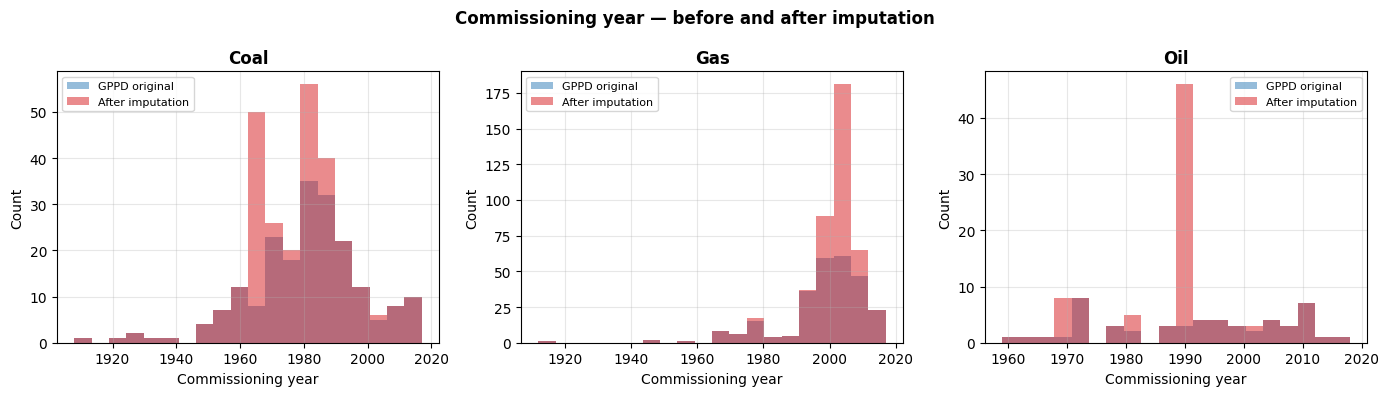

In [5]:
df = pd.concat([df_coal, df_other], ignore_index=True)

df['comm_year'] = df['commissioning_year']

# Priority 2: GCPT start year
mask = df['comm_year'].isna() & df['start_year_gcpt'].notna()
df.loc[mask, 'comm_year'] = df.loc[mask, 'start_year_gcpt']

# Priority 3: median country x fuel
medians = df.groupby(['country','fuel'])['comm_year'].median()
still = df['comm_year'].isna()
df.loc[still, 'comm_year'] = df.loc[still].apply(
    lambda r: medians.get((r['country'], r['fuel']), np.nan), axis=1
)

# Priority 4: median by fuel
fuel_med = df.groupby('fuel')['comm_year'].median()
still = df['comm_year'].isna()
df.loc[still, 'comm_year'] = df.loc[still, 'fuel'].map(fuel_med)
df['comm_year'] = df['comm_year'].round().astype(int)

print(f"Missing after imputation: {df['comm_year'].isna().sum()}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, fuel in zip(axes, ['coal','gas','oil']):
    sub = df[df['fuel']==fuel]
    ax.hist(sub['commissioning_year'].dropna(), bins=20, alpha=0.5, label='GPPD original', color='#2c7bb6')
    ax.hist(sub['comm_year'], bins=20, alpha=0.5, label='After imputation', color='#d7191c')
    ax.set_title(f'{fuel.capitalize()}', fontweight='bold')
    ax.set_xlabel('Commissioning year')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('Commissioning year — before and after imputation', fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig6_commissioning_year_imputation.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Age and remaining technical life (baseline year: 2020)

**Lifetimes:**
- Coal: **40 years** — IEA, Projected Costs of Generating Electricity 2020, p.36 (harmonised). Confirmed: Pfeiffer et al., Applied Energy 179 (2016): 1395-1408; Tong et al., Nature 572 (2019): 373-377.
- Gas: **35 years** — Project brief (projects_Peter_Tankov.pdf, p.15): explicit example in Rule-based retirement definition — *"coal: 40 years; gas: 35 years"*.
- Oil: **35 years** — Same source, by analogy with gas.


In [6]:
BASELINE_YEAR = 2020

LIFETIME = {'coal': 40, 'gas': 35, 'oil': 35}

df['age_2020']            = BASELINE_YEAR - df['comm_year']
df['lifetime']            = df['fuel'].map(LIFETIME)
df['remaining_life_2020'] = df['lifetime'] - df['age_2020']

print("Age distribution by fuel (2020):")
display(df.groupby('fuel')['age_2020'].describe()[['min','mean','50%','max']].round(1))
print(f"\nPlants technically past end-of-life in 2020: {(df['remaining_life_2020'] < 0).sum()}")
print(f"Plants technically past end-of-life in 2020 percentage: {(df['remaining_life_2020'] < 0 ).sum()/len(df)*100:.1f}%")
print(f"Plants with >10yr remaining life in 2020: {(df['remaining_life_2020'] > 10).sum()}")
print(f"Plants with >10yr remaining life in 2020 percentage: {(df['remaining_life_2020'] > 10).sum()/len(df)*100:.1f}%")

Age distribution by fuel (2020):


,min,mean,50%,max
fuel,,,,
coal,3.000,41.000,40.000,112.000
gas,3.000,20.300,18.000,108.000
oil,2.000,30.600,30.000,61.000



Plants technically past end-of-life in 2020: 195
Plants technically past end-of-life in 2020 percentage: 23.7%
Plants with >10yr remaining life in 2020: 436
Plants with >10yr remaining life in 2020 percentage: 52.9%


### 6. Emission factors and thermal efficiency η

**Emission factors** (tCO2/MWh thermal) — IPCC Guidelines for NGHGI 2006, Vol.2, Table 2.2, default values. Conversion: tCO2/TJ × 0.0036 = tCO2/MWh_th.  
Source: https://www.ipcc-nggip.iges.or.jp/public/2006gl/

| Fuel | IPCC EF (tCO2/TJ) | EF_th (tCO2/MWh_th) |
|---|---|---|
| Coal (hard coal default) | 94.6 | 0.341 |
| Gas | 56.1 | 0.202 |
| Oil | 74.1 | 0.267 |

**Thermal efficiency η** (fraction, LHV net, EU fleet average):

| Fuel | η | Source |
|---|---|---|
| Coal | 0.37 | IEA Clean Coal Centre (2016): EU fleet avg 38% LHV. JRC EUR 25406 EN (2012): 32-40% LHV for existing subcritical plants. Scientific Reports (2021): German coal fleet mean 37%. |
| Gas (CCGT) | 0.50 | JRC EUR 25406 EN (2012): 52-60% LHV for in-service CCGT. Scientific Reports (2021): German gas fleet mean 56%. UK DUKES: GB fleet ~46-47% GCV ≈ 51-52% LHV. Conservative mid-range for plants commissioned 1990-2015. |
| Oil (OCGT) | 0.35 | IEA 2020 Table 3.11b: OCGT efficiency 31-40% LHV. Oil plants are predominantly open-cycle peakers. |

**Carbon intensity ε** = ef_th / η (tCO2/MWh electric). Used in profit model: $C^{CO2}_{p,t} = \text{Carbon price}_t \times \epsilon_p$.

In [7]:
# Emission factors: IPCC Guidelines 2006, Vol.2, Table 2.2
# Conversion: tCO2/TJ * 0.0036 = tCO2/MWh_th
EF_FUEL = {
    'coal': 94.6 * 0.0036,   
    'gas' : 56.1 * 0.0036,
    'oil' : 74.1 * 0.0036,
}

# Thermal efficiency η (LHV net, EU existing fleet average)
# Coal 0.37: IEA CCC 2016 (EU avg 38%), JRC 2012 (32-40%), Sci.Rep. 2021 (DE mean 37%)
# Gas  0.50: JRC 2012 (52-60% CCGT), Sci.Rep. 2021 (DE mean 56%), UK DUKES (~51% LHV)
# Oil  0.35: IEA 2020 Table 3.11b OCGT (31-40%)
ETA_FUEL = {
    'coal': 0.37,
    'gas' : 0.50,
    'oil' : 0.35,
}

df['ef_th']  = df['fuel'].map(EF_FUEL)
df['eta']    = df['fuel'].map(ETA_FUEL)
df['epsilon'] = df['ef_th'] / df['eta']

print("Emission factors, efficiency, carbon intensity by fuel:")
display(df.groupby('fuel')[['ef_th','eta','epsilon']].mean().round(4))

Emission factors, efficiency, carbon intensity by fuel:


,ef_th,eta,epsilon
fuel,,,
coal,0.341,0.370,0.920
gas,0.202,0.500,0.404
oil,0.267,0.350,0.762


### 7. O&M costs

Variable O&M costs in EUR2024/MWh.  
Source: Derived from JRC (2012), EUR 25406 EN — O&M estimated at 4% of CAPEX per year, divided by annual full-load hours.  
Cross-checked against IEA 2020 country-level O&M data (Tables 3.11a, 3.12).  
Sensitised in Task 7.

| Fuel | O&M (EUR2024/MWh) | Derivation |
|---|---|---|
| Coal | 5.0 | IEA (2020) Table 3.12: 5–12 USD/MWh across EU. Lower bound retained for aged fleet. |
| Gas | 4.0 | IEA (2020) Table 3.11a: 5.7–7.0 USD/MWh total. Variable-only component retained. |
| Oil | 7.0 | Higher per-MWh due to very low utilisation (CF ~8%) and peaker plant economics |

In [8]:
OM_FUEL = {'coal': 5.0, 'gas': 4.0, 'oil': 7.0}
df['om_cost_eur_mwh'] = df['fuel'].map(OM_FUEL)
print("O&M costs (EUR2024/MWh):")
display(df.groupby('fuel')['om_cost_eur_mwh'].mean().round(1))

O&M costs (EUR2024/MWh):


fuel
coal   5.000
gas    4.000
oil    7.000
Name: om_cost_eur_mwh, dtype: float64

### 8. Capacity factor baseline 2020 from Eurostat

$$CF_{c,f,2020} = \frac{\text{GWh Eurostat}_{c,f,2020}}{\text{MW GPPD}_{c,f} \times 8760 / 1000}$$

Capped at CF_max = 0.85 — IEA 2020 p.36: physical upper bound for thermal plants (planned maintenance).  
Using the same source (Eurostat) and year (2020) for all three fuels ensures cross-fuel consistency. <br>

**Fallback:** Italy reports ':' (not available) for all of 2020 in this Eurostat extract — first valid year is 2022. For Italy only, 2022 is used as proxy for the 2020 baseline CF. Documented as a data limitation.

In [9]:
df_euro = pd.read_excel(
    '../../data/raw/nrg_cb_pem__custom_20732263_spreadsheet.xlsx',
    sheet_name='Data', header=None
)

EU27_EURO = [
    'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czechia','Denmark',
    'Estonia','Finland','France','Germany','Greece','Hungary','Ireland','Italy',
    'Latvia','Lithuania','Luxembourg','Malta','Netherlands','Poland','Portugal',
    'Romania','Slovakia','Slovenia','Spain','Sweden'
]
EURO_TO_ISO3 = {
    'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV','Cyprus':'CYP',
    'Czechia':'CZE','Denmark':'DNK','Estonia':'EST','Finland':'FIN','France':'FRA',
    'Germany':'DEU','Greece':'GRC','Hungary':'HUN','Ireland':'IRL','Italy':'ITA',
    'Latvia':'LVA','Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
    'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK','Slovenia':'SVN',
    'Spain':'ESP','Sweden':'SWE'
}
SECTION_ROWS = {'coal': 5, 'gas': 49, 'oil': 93}
CF_MAX = 0.85

def parse_eurostat_section(df_raw, start_row):
    time_row = start_row + 3
    time_cols = {}
    for col_idx in range(1, df_raw.shape[1], 2):
        val = df_raw.iloc[time_row, col_idx]
        if pd.notna(val):
            time_cols[str(val)] = col_idx
    records = []
    for row_idx in range(start_row + 5, df_raw.shape[0]):
        cname = df_raw.iloc[row_idx, 0]
        if pd.isna(cname): continue
        cname = str(cname).strip()
        if cname not in EU27_EURO: continue
        for t, col_idx in time_cols.items():
            val = pd.to_numeric(df_raw.iloc[row_idx, col_idx], errors='coerce')
            records.append({'country': EURO_TO_ISO3[cname], 'year_month': t,
                            'gwh': val if pd.notna(val) else 0.0})
    return pd.DataFrame(records)

euro_parts = []
for fuel, start_row in SECTION_ROWS.items():
    sec = parse_eurostat_section(df_euro, start_row)
    sec['fuel'] = fuel
    euro_parts.append(sec)

euro_long = pd.concat(euro_parts, ignore_index=True)
euro_long['year'] = euro_long['year_month'].str[:4].astype(int)

# Primary: 2020. Fallback: 2022 if 2020 = ':' (Eurostat not available) — case: Italy
gwh_by_year = euro_long.groupby(['country','fuel','year'])['gwh'].sum().reset_index()
gwh_2020 = (gwh_by_year[gwh_by_year['year'] == 2020]
            .rename(columns={'gwh': 'gwh_2020'}).drop(columns='year'))
gwh_2022 = (gwh_by_year[gwh_by_year['year'] == 2022]
            .rename(columns={'gwh': 'gwh_2022'}).drop(columns='year'))
euro_2020 = gwh_2020.merge(gwh_2022, on=['country','fuel'], how='left')
fallback_mask = (euro_2020['gwh_2020'] == 0) & (euro_2020['gwh_2022'].fillna(0) > 0)
print(f"2022 proxy used for {fallback_mask.sum()} (country, fuel) pairs:")
if fallback_mask.any():
    print(euro_2020[fallback_mask][['country','fuel']].to_string(index=False))
euro_2020.loc[fallback_mask, 'gwh_2020'] = euro_2020.loc[fallback_mask, 'gwh_2022']
euro_2020 = euro_2020[['country','fuel','gwh_2020']]

cap_cf = (
    df.groupby(['country','fuel'])['capacity_mw'].sum()
    .reset_index().rename(columns={'capacity_mw':'cap_mw'})
)

cf_base = euro_2020.merge(cap_cf, on=['country','fuel'], how='left')
cf_base['cf_baseline'] = cf_base['gwh_2020'] / (cf_base['cap_mw'] * 8760 / 1000)
cf_base['cf_baseline'] = cf_base['cf_baseline'].clip(upper=CF_MAX).fillna(0.0)

print("Capacity factor baseline 2020 by fuel:")
display(cf_base.groupby('fuel')['cf_baseline'].describe()[['min','mean','50%','max']].round(3))

2022 proxy used for 3 (country, fuel) pairs:
country fuel
    ITA coal
    ITA  gas
    ITA  oil
Capacity factor baseline 2020 by fuel:


,min,mean,50%,max
fuel,,,,
coal,0.000,0.434,0.422,0.850
gas,0.000,0.376,0.341,0.850
oil,0.000,0.085,0.000,0.850


### 9. Sanity check — CF Eurostat vs CF GCPT (coal only)

For matched coal plants, we compare our country-level Eurostat CF against the plant-level GCPT CF.  
Agreement within ±20% validates the calibration. Residual dispersion is expected: Eurostat is country-level, GCPT is plant-level.

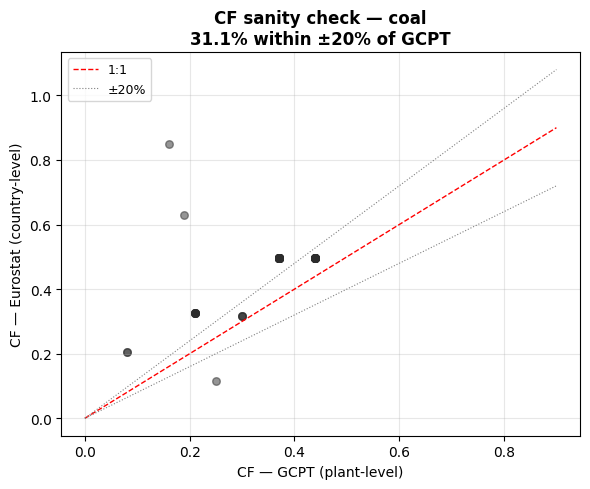

In [10]:
df = df.merge(cf_base[['country','fuel','cf_baseline']], on=['country','fuel'], how='left')
df['cf_baseline'] = df['cf_baseline'].fillna(0.0)

coal_matched = df[(df['fuel']=='coal') & df['cf_gcpt'].notna() & (df['cf_gcpt'] > 0)].copy()

if len(coal_matched) > 0:
    coal_matched['cf_diff_pct'] = abs(coal_matched['cf_baseline'] - coal_matched['cf_gcpt']) / coal_matched['cf_gcpt'] * 100
    within_20 = (coal_matched['cf_diff_pct'] <= 20).mean() * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(coal_matched['cf_gcpt'], coal_matched['cf_baseline'], alpha=0.5, color='#2c2c2c', s=30)
    lim = max(coal_matched['cf_gcpt'].max(), coal_matched['cf_baseline'].max()) + 0.05
    ax.plot([0, lim], [0, lim],       'r--', linewidth=1, label='1:1')
    ax.plot([0, lim], [0, lim*1.2],   ':',  color='grey', linewidth=0.8, label='±20%')
    ax.plot([0, lim], [0, lim*0.8],   ':',  color='grey', linewidth=0.8)
    ax.set_xlabel('CF — GCPT (plant-level)')
    ax.set_ylabel('CF — Eurostat (country-level)')
    ax.set_title(f'CF sanity check — coal\n{within_20:.1f}% within ±20% of GCPT', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../../outputs/figures/fig7_cf_sanity_check.png', dpi=150, bbox_inches='tight')
    plt.show()

### 10. Capacity factor evolution under NGFS scenarios

$$CF_{c,f,t,s} = CF_{c,f,2020} \times \frac{\text{NGFS}_{f,t,s}}{\text{NGFS}_{f,2020,s}}$$

Capped at CF_max = 0.85. Output used for utilisation stranding robustness check (Task 7).  
EU average capacity factor trajectories are plotted for all three fuels.

Saved: data/processed/ngfs_cf_evolution.csv  |  Shape: (5580, 5)


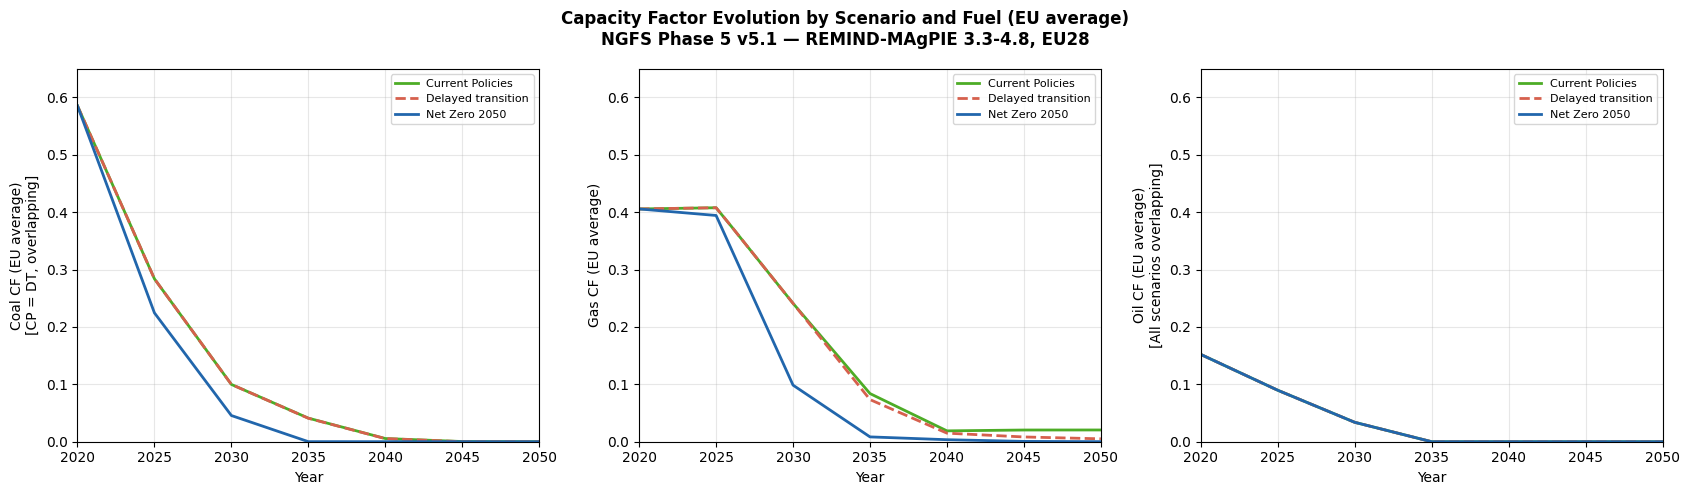

Fuel prices converted and saved to ngfs_scenarios_elec.csv: EUR2024/MWh_th → EUR2024/MWh_elec


In [11]:
ngfs = pd.read_csv('../../data/processed/ngfs_scenarios.csv')

NGFS_GEN_VARS = {
    'coal': 'Secondary Energy|Electricity|Coal',
    'gas' : 'Secondary Energy|Electricity|Gas',
    'oil' : 'Secondary Energy|Electricity|Oil',
}

cf_evo_records = []
for fuel, var in NGFS_GEN_VARS.items():
    gen = ngfs[ngfs['variable'] == var][['scenario','year','value']].copy()
    gen_2020 = gen[gen['year'] == 2020].set_index('scenario')['value']
    countries = df[df['fuel'] == fuel]['country'].unique()

    for country in countries:
        cf_b_row = cf_base[(cf_base['country'] == country) & (cf_base['fuel'] == fuel)]
        if len(cf_b_row) == 0: continue
        cf_b = cf_b_row['cf_baseline'].values[0]

        for scenario in gen['scenario'].unique():
            gen_s  = gen[gen['scenario'] == scenario].set_index('year')['value']
            base_v = gen_2020.get(scenario, np.nan)
            if pd.isna(base_v) or base_v == 0: continue

            for year in range(2020, 2051):
                ratio = gen_s.get(year, np.nan) / base_v
                cf_t  = float(np.clip(cf_b * ratio, 0, CF_MAX)) if pd.notna(ratio) else 0.0
                cf_evo_records.append({'country': country, 'fuel': fuel,
                                       'scenario': scenario, 'year': year, 'cf': round(cf_t, 4)})

df_cf_evo = pd.DataFrame(cf_evo_records)
df_cf_evo.to_csv('../../data/processed/ngfs_cf_evolution.csv', index=False)
print(f"Saved: data/processed/ngfs_cf_evolution.csv  |  Shape: {df_cf_evo.shape}")

SCENARIO_COLORS    = {'Net Zero 2050':'#2166ac','Delayed transition':'#d6604d','Current Policies':'#4dac26'}
SCENARIO_LINESTYLE = {'Net Zero 2050':'-','Delayed transition':'--','Current Policies':'-'}
FUEL_TITLES = {
    'coal': 'Coal CF (EU average)\n[CP = DT, overlapping]',
    'gas' : 'Gas CF (EU average)',
    'oil' : 'Oil CF (EU average)\n[All scenarios overlapping]',
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)

for ax, fuel in zip(axes, ['coal', 'gas', 'oil']):
    fuel_avg = df_cf_evo[df_cf_evo['fuel'] == fuel].groupby(['scenario','year'])['cf'].mean().reset_index()
    for scenario, grp in fuel_avg.groupby('scenario'):
        ax.plot(grp['year'], grp['cf'],
                color=SCENARIO_COLORS.get(scenario, 'grey'),
                linestyle=SCENARIO_LINESTYLE.get(scenario, '-'),
                linewidth=2, label=scenario)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(FUEL_TITLES[fuel], fontsize=10)
    ax.set_xlim(2020, 2050)
    ax.set_ylim(0, 0.65)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Capacity Factor Evolution by Scenario and Fuel (EU average)\nNGFS Phase 5 v5.1 — REMIND-MAgPIE 3.3-4.8, EU28',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/figures/fig8_cf_evolution_all_fuels.png', dpi=150, bbox_inches='tight')
plt.show()



# Convert NGFS fuel prices: EUR2024/MWh_th → EUR2024/MWh_elec (divide by η)
# Guard: skip if already converted (prevents double-division on re-run)
sample_unit = ngfs.loc[ngfs['variable'] == 'Price|Primary Energy|Coal', 'unit'].iloc[0]
if sample_unit == 'EUR2024/MWh':
    for var, fuel in [
        ('Price|Primary Energy|Coal', 'coal'),
        ('Price|Primary Energy|Gas',  'gas'),
        ('Price|Primary Energy|Oil',  'oil'),
    ]:
        mask = ngfs['variable'] == var
        ngfs.loc[mask, 'value'] = ngfs.loc[mask, 'value'] / ETA_FUEL[fuel]
        ngfs.loc[mask, 'unit']  = 'EUR2024/MWh_elec'
    ngfs.to_csv('../../data/processed/ngfs_scenarios_elec.csv', index=False)
    print('Fuel prices converted and saved to ngfs_scenarios_elec.csv: EUR2024/MWh_th → EUR2024/MWh_elec')
else:
    print(f'Fuel prices already in {sample_unit} — no conversion applied (ngfs_scenarios_elec.csv)')



### 11. Save gppd_eu_metrics.csv

**Columns for the profit margin formula π (Task 4):**
- `carbon_intensity_tCO2_per_MWh_elec` : ε = ef_th/η (tCO2/MWh_elec) → $C^{CO2}_{p,t}$ = carbon price × this column
- `om_variable_eur2024_per_MWh` : EUR2024/MWh_elec → directly $C^{O\&M}_p$
- Fuel cost: use `Price|Primary Energy|[fuel]` from `ngfs_scenarios_elec.csv` directly — already in EUR2024/MWh_elec after Task 3

**Columns for rule-based stranding (Task 4):**
- `commissioning_year` : plant commissioning year
- `remaining_life_2020_years` : plant stranded under rule-based definition if year > 2020 + this value
- `lifetime` : technical lifetime (years)

**Columns for aggregation (Task 5):**
- `capacity_mw` : MW — capacity-weighted aggregation
- `age_2020_years` : vintage pre/post 2000
- `country`, `fuel` : aggregation dimensions

**Columns for utilisation stranding (Task 7):**
- `capacity_factor_2020` : 2020 baseline capacity factor


In [12]:
COLS_FINAL = [
    'gppd_idnr', 'name', 'country', 'country_long',
    'fuel',
    'capacity_mw',
    'comm_year', 'age_2020', 'lifetime', 'remaining_life_2020',
    'epsilon',
    'om_cost_eur_mwh',
    'cf_baseline',
    'latitude', 'longitude',
]

cols_present = [c for c in COLS_FINAL if c in df.columns]
df_out = df[cols_present].copy().reset_index(drop=True)

df_out = df_out.rename(columns={
    'comm_year'           : 'commissioning_year',
    'age_2020'            : 'age_2020_years',
    'remaining_life_2020' : 'remaining_life_2020_years',
    'epsilon'             : 'carbon_intensity_tCO2_per_MWh_elec',
    'om_cost_eur_mwh'     : 'om_variable_eur2024_per_MWh',
    'cf_baseline'         : 'capacity_factor_2020',
})

df_out.to_csv('../../data/processed/gppd_eu_metrics.csv', index=False)

print(f"Saved: data/processed/gppd_eu_metrics.csv")
print(f"Shape : {df_out.shape[0]:,} plants x {df_out.shape[1]} columns")
print()
print('Summary by fuel:')
display(
    df_out.groupby('fuel')[[
        'capacity_mw',
        'age_2020_years',
        'carbon_intensity_tCO2_per_MWh_elec',
        'om_variable_eur2024_per_MWh',
        'capacity_factor_2020'
    ]].mean().round(3)
)

Saved: data/processed/gppd_eu_metrics.csv
Shape : 824 plants x 15 columns

Summary by fuel:


,capacity_mw,age_2020_years,carbon_intensity_tCO2_per_MWh_elec,om_variable_eur2024_per_MWh,capacity_factor_2020
fuel,,,,,
coal,513.463,41.014,0.920,5.000,0.489
gas,323.846,20.251,0.404,4.000,0.386
oil,272.943,30.566,0.762,7.000,0.146


In [13]:
zero_cf = df[df['cf_baseline'] == 0.0]
print(f"CF=0 restants : {len(zero_cf)} plantes / {zero_cf['capacity_mw'].sum():,.0f} MW")
print(zero_cf.groupby(['country','fuel']).agg(n=('gppd_idnr','count'), cap_mw=('capacity_mw','sum')))

CF=0 restants : 6 plantes / 2,919 MW
              n    cap_mw
country fuel             
EST     gas   2   423.000
        oil   2 1,841.000
POL     oil   2   655.000
